In [1]:
from google.colab import files
uploaded = files.upload()

Saving Lab Session Data.xlsx to Lab Session Data.xlsx


In [24]:
import pandas as pd
import numpy as np
import io
df = pd.read_excel(io.BytesIO(uploaded['Lab Session Data.xlsx']) , sheet_name="Purchase data")
df.set_index('Customer', inplace=True)
# df
# A=df.iloc[:,1:4]
# print(A)
# C=df.iloc[:,4:5]
# print(C)
df=df.iloc[0:10,0:4]
Candies= df["Candies (#)"]
Mangoes = df["Mangoes (Kg)"]
Milk_Packets = df["Milk Packets (#)"]
Payment = df["Payment (Rs)"]
A = np.column_stack((Candies, Mangoes, Milk_Packets))
C = Payment.values
pseudo_inv = np.linalg.pinv(A)
X = pseudo_inv.dot(C)
rank_A = np.linalg.matrix_rank(A)
print(A)
print("The dimensionality of the vector space is the rank of the matrix")
print("The number of vectors in this vector space are ",rank_A)
print("Rank of A:", rank_A)
print("The cost of each product are ",X,"respectively.")

[[20  6  2]
 [16  3  6]
 [27  6  2]
 [19  1  2]
 [24  4  2]
 [22  1  5]
 [15  4  2]
 [18  4  2]
 [21  1  4]
 [16  2  4]]
The dimensionality of the vector space is the rank of the matrix
The number of vectors in this vector space are  3
Rank of A: 3
The cost of each product are  [ 1. 55. 18.] respectively.


In [25]:
df['Customer Status'] = np.where(Payment > 200, 'Rich', 'Poor')

# Display the updated DataFrame
#print(df)
df

,Candies (#),Mangoes (Kg),Milk Packets (#),Payment (Rs),Customer Status
Customer,,,,,
C_1,20,6,2,386,Rich
C_2,16,3,6,289,Rich
C_3,27,6,2,393,Rich
C_4,19,1,2,110,Poor
C_5,24,4,2,280,Rich
C_6,22,1,5,167,Poor
C_7,15,4,2,271,Rich
C_8,18,4,2,274,Rich
C_9,21,1,4,148,Poor


In [32]:
df2 = pd.read_excel('Lab Session Data.xlsx',sheet_name="IRCTC Stock Price")
mean=df2["Price"].mean()
var=df2["Price"].var()
print("Mean:",mean)
print("Variance:",var)

Mean: 1560.6634538152612
Variance: 58732.36535253918


In [35]:
df_wed=df2[df2['Day'] =='Wed']
df_wed
df_wed['Price'].mean()

1550.7060000000001

In [37]:
df_apr=df2[df2['Month'] =='Apr']
df_apr["Price"].mean()

1698.9526315789474

In [41]:
loss=df2['Chg%'].apply(lambda x : x<0)
loss

numberOfTrues=loss.sum()
totalRows=len(loss)

print(numberOfTrues/totalRows)

0.4979919678714859


In [45]:
wednesday_stock=df_wed['Chg%']
profit=wednesday_stock.apply(lambda x : x>0)
profit.sum()/len(profit)

0.08433734939759036

Text(0.5, 1.0, 'Scatter Plot of Chg% by Day of the Week')

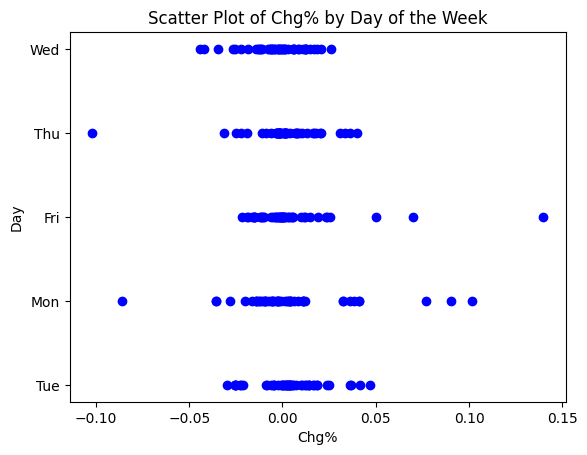

In [47]:
import matplotlib.pyplot as plt
plt.scatter(df2['Chg%'], df2['Day'], color='blue', marker='o')
plt.xlabel('Chg%')
plt.ylabel('Day')
plt.title('Scatter Plot of Chg% by Day of the Week')